In [1]:
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')
import codes.toolbox as tb

import warnings
warnings.filterwarnings("ignore")

from importlib import reload
reload(tb)

<module 'codes.toolbox' from '/Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/../codes/toolbox.py'>

In [2]:
dl = tb.DataLoader('../data')
dl

DataLoader(symbols=0GUSDT .. ZRXUSDT (535 symbols), exchanges=(binance, bitget, bybit, okex), instruments=(futures, perps, spot, swap), dates=20250701 .. 20260412 (286 days))

In [3]:
dl.columns

['ts',
 'close',
 'volume_usdt',
 'cvd_usdt',
 'open_interest',
 'funding_rate',
 'funding_interval_hours']

In [4]:
def sigmoid(arr):
    return 1.0/(1.0 + np.exp(-1.0*arr))

def transformY(y, smooth = 0.0):
    if smooth < 1e-8:
        return (np.sign(y)+1.0)/2.0
    return sigmoid(y/smooth)

In [5]:
def showPricePred(price_mat, pred_mat):
    plt.figure(figsize=(12,4))
    for i in range(price_mat.shape[0]):
        plt.subplot(1, 2, 1)
        plt.plot(price_mat[i,:], color = 'grey', alpha = 0.1)
        plt.subplot(1, 2, 2)
        plt.plot(pred_mat[i,:], color = 'grey', alpha = 0.1)
    max_idx = np.arange(len(price_mat[0,]))[price_mat[0] == 1.0]
    plt.subplot(1,2,1)
    plt.title('price')
    plt.plot(np.mean(price_mat, axis = 0), color = 'red')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.title('prediction')
    plt.axhline(0, color = 'black', linestyle = 'dashed')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.plot(np.mean(pred_mat, axis = 0), color = 'red')
    plt.grid(True)

def binToDirectionY(ypred, central = 0.5):
    return (ypred-central)*2.0

def plotHistogram(model, X, X_valid, centralize=True):
    ypred_train = model.predict(X)
    ypred_valid = model.predict(X_valid)
    if centralize:
        central = np.median(ypred_train)
        ypred_train = binToDirectionY(ypred_train, central)
        ypred_valid = binToDirectionY(ypred_valid, central)

    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.hist(ypred_train, bins = 100)
    plt.grid(True)
    plt.title('ytrain pred centered')

    plt.subplot(1,2,2)
    plt.hist(ypred_valid, bins = 100)
    plt.grid(True)
    plt.title('yvalid pred centered')

    plt.tight_layout()
    if centralize:
        return central
    return 0
    
def evalModelTrain(model, X_norm, Y, O, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ypred = model.predict(X_norm)
    if ypred_trans is not None:
        ypred = ypred_trans(ypred)

    cutoffs = np.quantile(abs(ypred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(ypred, Y, O, cutoffs, eval_horizon = eval_horizon, statCol = statCol, cutoff_names = cutoff_names)


def evalModelValid(model, X_train, X_valid, Y_valid, O_valid, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ytrain_pred = model.predict(X_norm)
    yvalid_pred = model.predict(X_valid)
    if ypred_trans is not None:
        yvalid_pred = ypred_trans(yvalid_pred)
        ytrain_pred = ypred_trans(ytrain_pred)

    cutoffs = np.quantile(abs(ytrain_pred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(yvalid_pred, Y_valid, O_valid, cutoffs, eval_horizon = eval_horizon, 
                            statCol = statCol, cutoff_names = cutoff_names)

## LoadData

In [6]:
train_symbols = dl.symbols[::2]
valid_symbols = dl.symbols[1::2]

#features = ['dprice_ratio', 'dvolume_usdt_ratio', 'dcvd_usdt', 'doi', 'cvd_usdt']
features = ['dprice_es4', 'dprice_ratio_es4', 'dprice_es8', 'dprice_ratio_es8',
       'dprice_es24', 'dprice_ratio_es24', 'oi_es4', 'doi_es4', 'doi_ratio_es4', 'oi_native_es4', 'doi_native_es4',
       'doi_native_ratio_es4', 'cvd_es4', 'cvd_es8', 'cvd_es24', 'dcvd_es4', 'dcvd_es8', 'dcvd_es24', 'dcvd_ratio_es4', 'dcvd_ratio_es8',
       'cvd_vol_es4', 'cvd_vol_es8', 'dcvd_vol_es4', 'dcvd_vol_es8',
       'dcvd_ratio_es24', 'abs_cvd_ema240', 'cvd_es4_norm', 'dcvd_es4_norm','cvd_es8_norm', 'dcvd_es8_norm', 'cvd_es24_norm', 'dcvd_es24_norm',
       'd_abs_cvd_es_bar_es4', 'd_abs_cvd_es_bar_ratio_es4', 'd_abs_cvd_es_bar_es4_norm', 'spot_cvd_es4', 'spot_cvd_es8',
       'spot_cvd_es24', 'dspot_cvd_es4', 'dspot_cvd_es8', 'dspot_cvd_es24','dspot_cvd_ratio_es4', 'dspot_cvd_ratio_es8', 
       'dspot_cvd_ratio_es24', 'spot_cvd_es4_norm', 'dspot_cvd_es4_norm', 'spot_cvd_es8_norm', 'dspot_cvd_es8_norm', 
       'spot_cvd_es24_norm', 'dspot_cvd_es24_norm', 'd_abs_spot_cvd_es_bar_es4', 'd_abs_spot_cvd_es_bar_ratio_es4', 
       'd_abs_spot_cvd_es_bar_es4_norm', 'funding_rate', 'funding_rate_avg', 'spot_fut_vol_ratio', 'spot_fut_vol_es24_ratio']

horizons = [1,2,4,8,12, 16, 24, 32, 40, 48, 72]

markets = 'binance'
instruments = 'futures'

barFreq = 4

df_train = tb.agg_futures_data(dl, train_symbols, markets, instruments, barFreq=barFreq, sampleFreq=1)
returns = tb.makeReturns(dl, df_train, horizons = horizons, adjustFundingRate=True,
                         addPumpLabel=True,
                          pumpThreshold=1.5,      
                          pumpForwardHours=7*24,
                          pumpMinHistoryHours=3*24)


X, Y, O = tb.makeXY(df_train, returns, features, appender=['volume_usdt'])

df_valid =  tb.agg_futures_data(dl, valid_symbols, markets, instruments, barFreq=barFreq, sampleFreq=1)
returns = tb.makeReturns(dl, df_valid, horizons = horizons, adjustFundingRate=True,
                         addPumpLabel=True,
                          pumpThreshold=1.5,      
                          pumpForwardHours=7*24,
                          pumpMinHistoryHours=3*24)

X_valid, Y_valid, O_valid = tb.makeXY(df_valid, returns, features, appender=['volume_usdt'])

print ('trainX.shape', X.shape)
print ('validX.shape', X_valid.shape) 

NameError: name 'df_train' is not defined

In [7]:
Dataset = {'X_train': X, 'Y_train': Y, 'O_train': O, 'X_valid': X_valid, 'Y_valid': Y_valid, 'O_valid': O_valid}
tb.savePickle(Dataset, './stockSplitData_0.pkl')

NameError: name 'X' is not defined

In [8]:
Dataset = tb.loadPickle('./stockSplitData_0.pkl')
X = Dataset['X_train']
Y = Dataset['Y_train']
O = Dataset['O_train'] 
X_valid = Dataset['X_valid'] 
Y_valid = Dataset['Y_valid']
O_valid = Dataset['O_valid']

In [9]:
normalizer = tb.FeatureStater(group_mode = 'all', quantiles = (0.005, 0.995)) 
normalizer.fit(X, O)
X_norm = normalizer.transform(X,O, clip=True)
X_valid_norm = normalizer.transform(X_valid, O_valid, clip = True)

## Binary Classifcation

In [10]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 4,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 20,           # min data points in a leaf

    "learning_rate": 0.01,
    "n_estimators": 500,              # or use num_boost_round in lgb.train()

    "subsample": 0.6,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.6,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [23]:
model, loss_path = tb.fitLgb(X_norm, transformY(Y['ret_24h'].values),  params, log_period=20)

[20]	train's binary_logloss: 0.688511	train's auc: 0.565606	val's binary_logloss: 0.688511	val's auc: 0.565606
[40]	train's binary_logloss: 0.687071	train's auc: 0.567336	val's binary_logloss: 0.687071	val's auc: 0.567336
[60]	train's binary_logloss: 0.685959	train's auc: 0.568695	val's binary_logloss: 0.685959	val's auc: 0.568695
[80]	train's binary_logloss: 0.685061	train's auc: 0.569586	val's binary_logloss: 0.685061	val's auc: 0.569586
[100]	train's binary_logloss: 0.684340	train's auc: 0.570483	val's binary_logloss: 0.684340	val's auc: 0.570483
[120]	train's binary_logloss: 0.683726	train's auc: 0.571366	val's binary_logloss: 0.683726	val's auc: 0.571366
[140]	train's binary_logloss: 0.683200	train's auc: 0.572183	val's binary_logloss: 0.683200	val's auc: 0.572183
[160]	train's binary_logloss: 0.682716	train's auc: 0.573051	val's binary_logloss: 0.682716	val's auc: 0.573051
[180]	train's binary_logloss: 0.682313	train's auc: 0.573878	val's binary_logloss: 0.682313	val's auc: 0.573

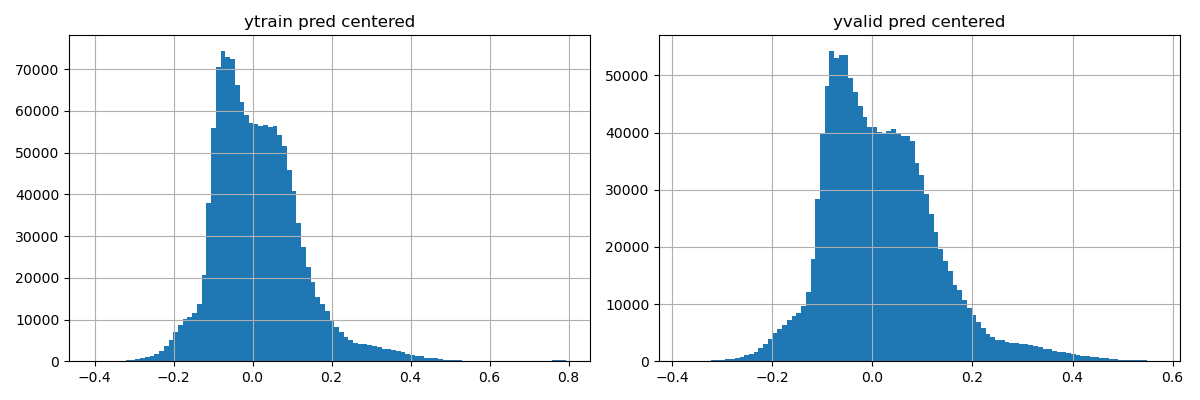

In [24]:
central = plotHistogram(model, X_norm, X_valid_norm, centralize=True)

In [25]:
ypred_train = model.predict(X_norm)
ypred_valid = model.predict(X_valid_norm)
central     = np.median(ypred_train)
ypred_train = binToDirectionY(ypred_train, central)
ypred_valid = binToDirectionY(ypred_valid, central)

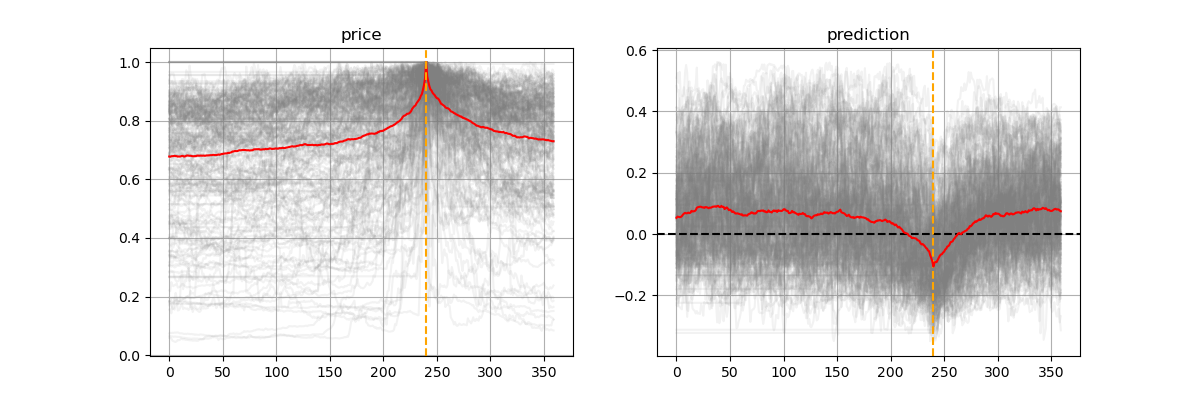

In [26]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_train, O)
showPricePred(price_mat, pred_mat)

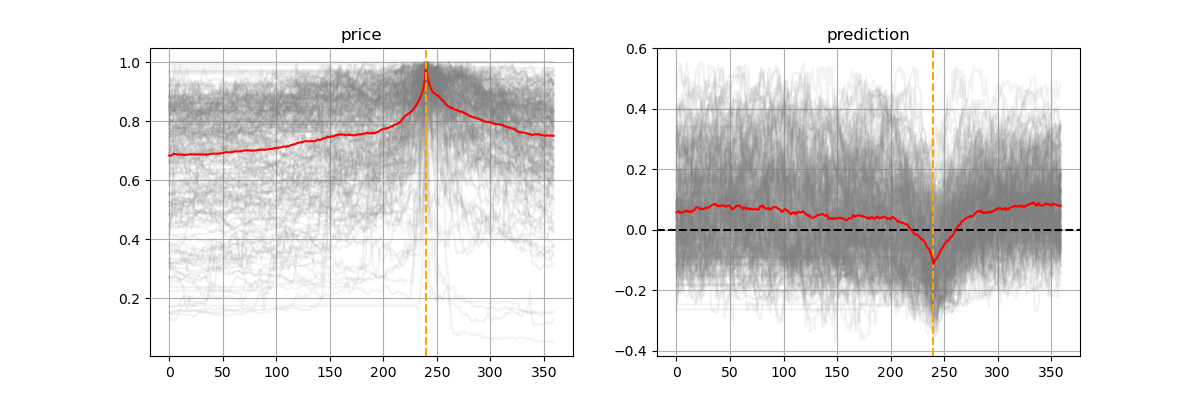

In [27]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_valid, O_valid)
showPricePred(price_mat, pred_mat)

## Positive Prediction

In [11]:
def shiftY(y, pivot, steep):
    return sigmoid((y-pivot)/steep)

def binaryLabel(y, cutoff = 0):
    return 1.0*(y > cutoff)

In [59]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss
    "scale_pos_weight": 50.0,

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 2,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 50,           # min data points in a leaf

    "learning_rate": 0.01,
    "n_estimators": 100,              # or use num_boost_round in lgb.train()

    "subsample": 0.6,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.6,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [60]:
#Yshift = binaryLabel(Y['ret_24h'].values, 0.2)
#pos_ratio = np.sum(Yshift)/(Yshift.shape[0] - np.sum(Yshift))
#pos_ratio

In [61]:
pump_label = Y['pump_label'].values
pos_ratio = np.sum(pump_label)/(pump_label.shape[0] - np.sum(pump_label))

In [62]:
params['scale_pos_weight'] = 0.1*1.0/pos_ratio
model_binary, loss_path = tb.fitLgb(X_norm, pump_label,  params, log_period=10) #Yshift

[10]	train's binary_logloss: 0.051821	train's auc: 0.820581	val's binary_logloss: 0.051821	val's auc: 0.820581
[20]	train's binary_logloss: 0.053226	train's auc: 0.835529	val's binary_logloss: 0.053226	val's auc: 0.835529
[30]	train's binary_logloss: 0.055741	train's auc: 0.839744	val's binary_logloss: 0.055741	val's auc: 0.839744
[40]	train's binary_logloss: 0.058451	train's auc: 0.844692	val's binary_logloss: 0.058451	val's auc: 0.844692
[50]	train's binary_logloss: 0.061201	train's auc: 0.846606	val's binary_logloss: 0.061201	val's auc: 0.846606
[60]	train's binary_logloss: 0.063936	train's auc: 0.849829	val's binary_logloss: 0.063936	val's auc: 0.849829
[70]	train's binary_logloss: 0.066497	train's auc: 0.851225	val's binary_logloss: 0.066497	val's auc: 0.851225
[80]	train's binary_logloss: 0.068880	train's auc: 0.853706	val's binary_logloss: 0.068880	val's auc: 0.853706
[90]	train's binary_logloss: 0.071054	train's auc: 0.855000	val's binary_logloss: 0.071054	val's auc: 0.855000
[

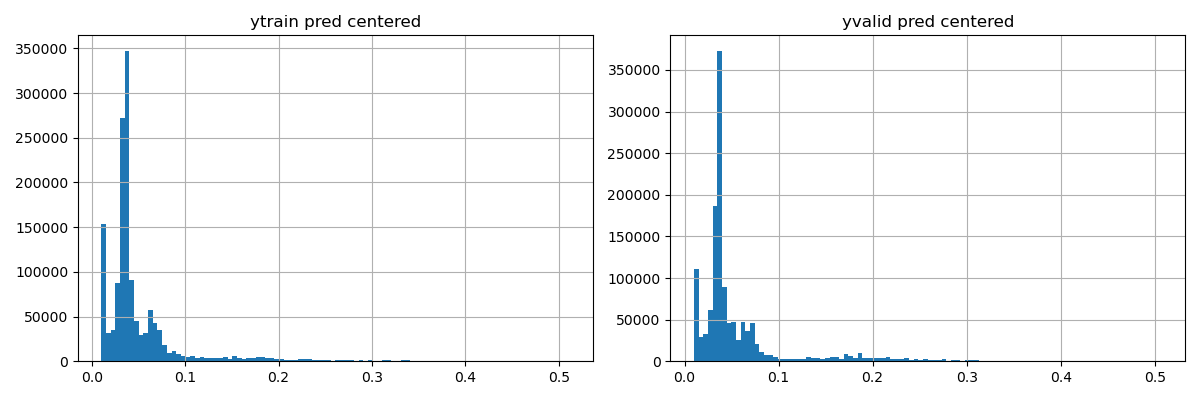

In [63]:
central = plotHistogram(model_binary, X_norm, X_valid_norm, centralize=False)

In [64]:
ypred_train = model_binary.predict(X_norm)
ypred_valid = model_binary.predict(X_valid_norm)

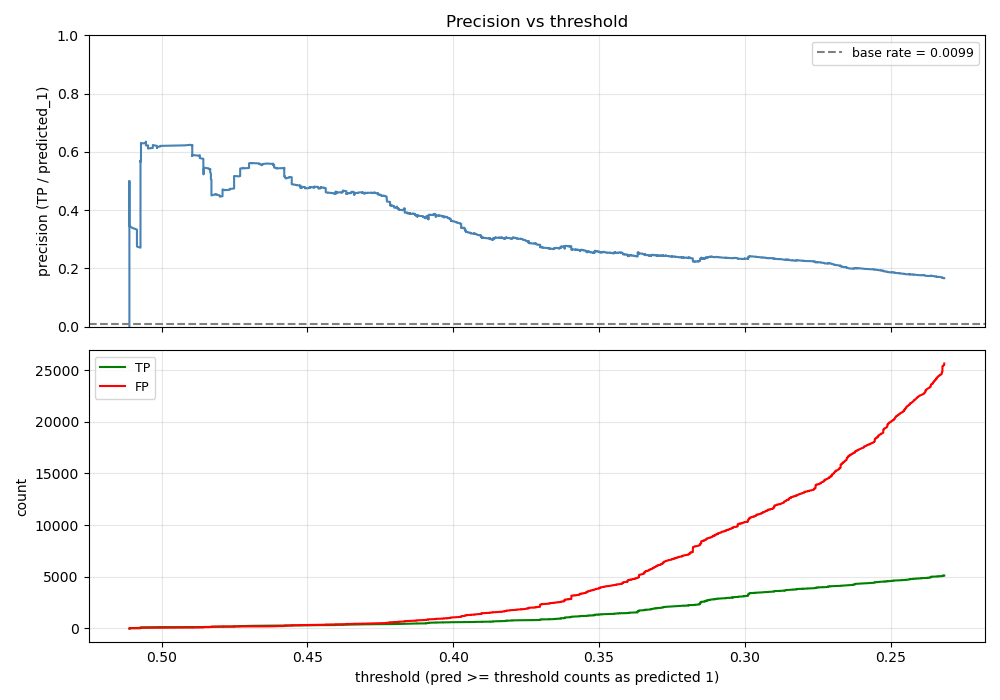

In [65]:
_ = tb.plotPrecisionByThreshold(ypred_train, Y['pump_label'].values)

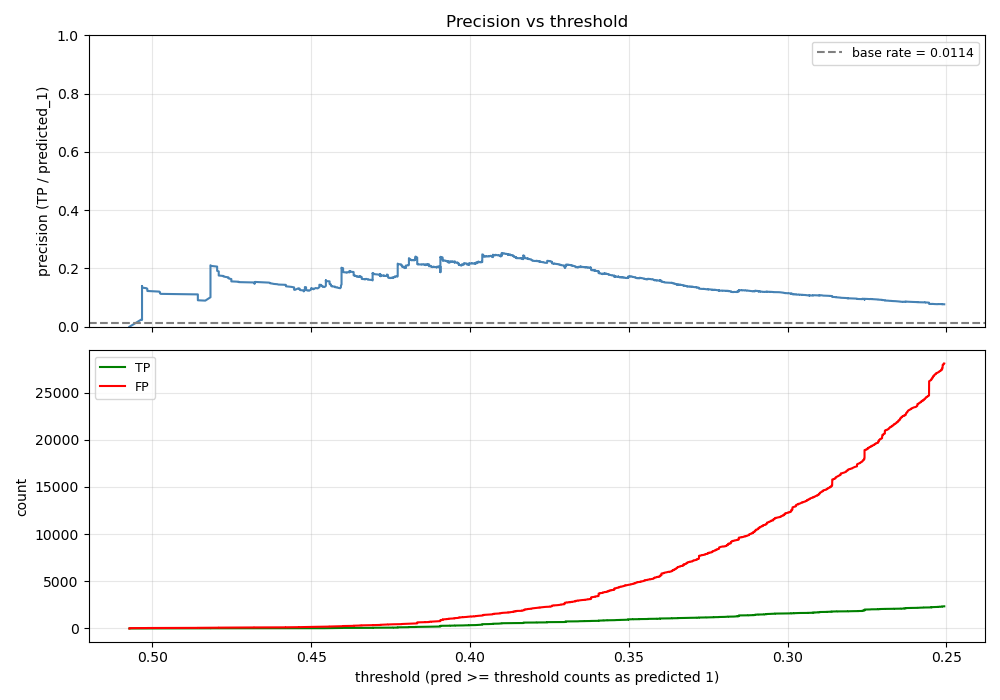

In [66]:
_ = tb.plotPrecisionByThreshold(ypred_valid, Y_valid['pump_label'].values)

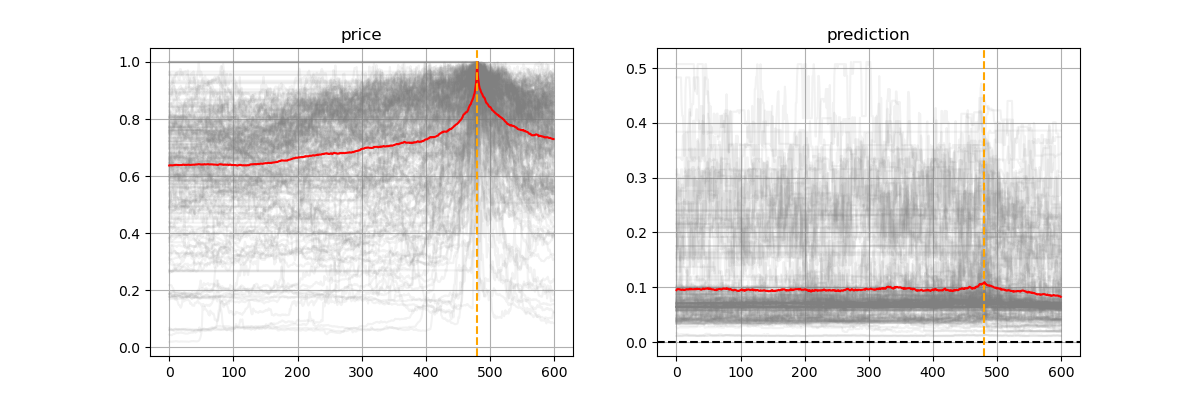

In [67]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_train, O, left_days=20)
showPricePred(price_mat, pred_mat)

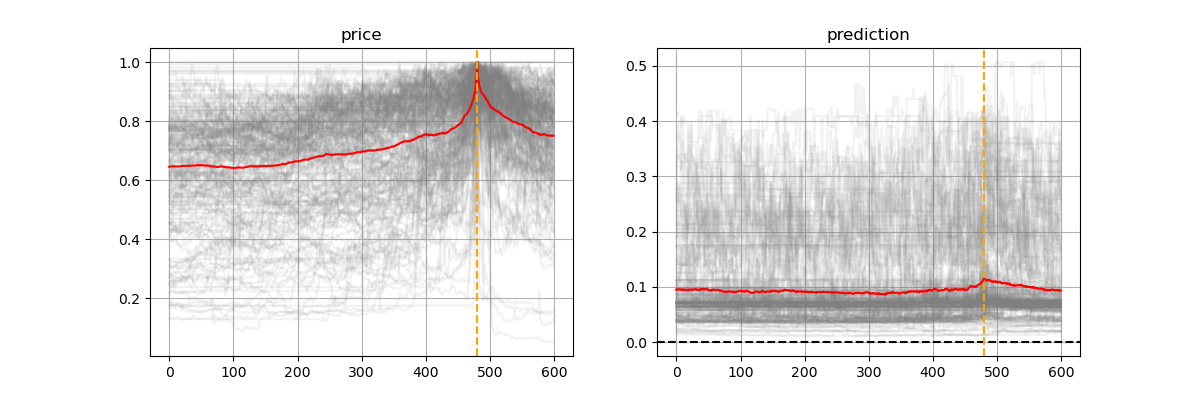

In [68]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_valid , O_valid, left_days=20)
showPricePred(price_mat, pred_mat)

In [69]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 0.40, 1.0, 0.0), O_valid)
train_long_short = tb.causal_long_short(np.where(ypred_train > 0.40, 1.0, 0.0), O)

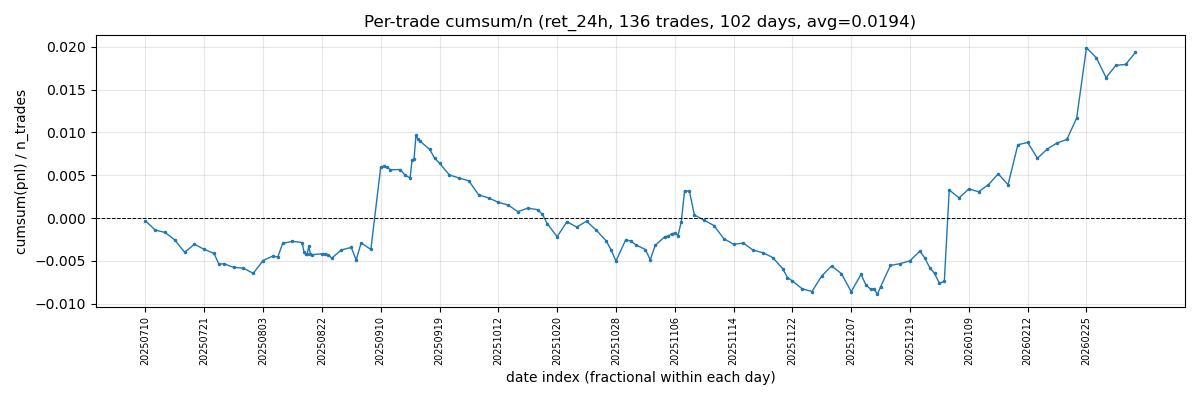

In [72]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_24h')

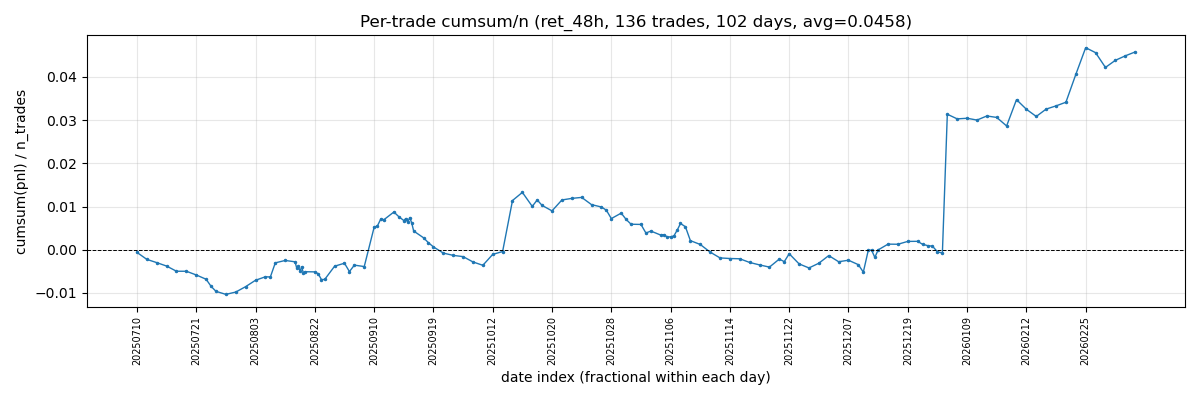

In [73]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_48h')

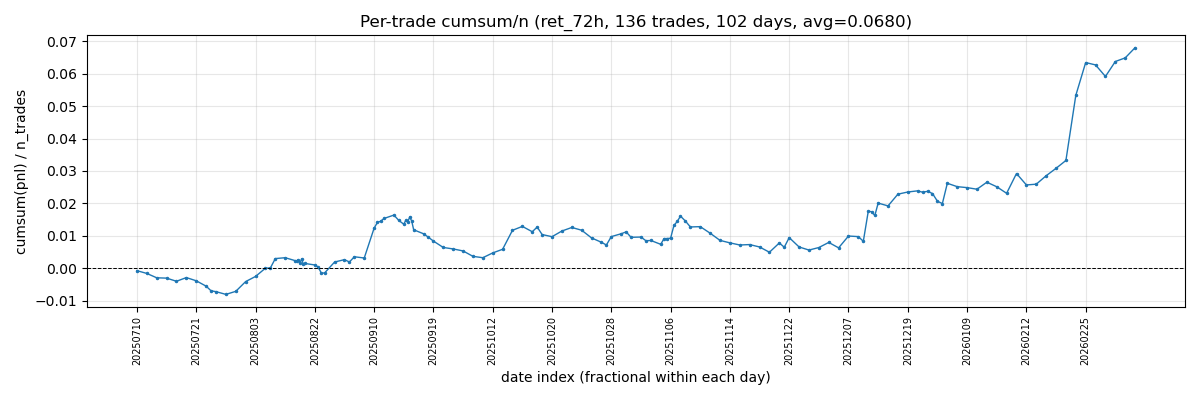

In [74]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_72h')

In [31]:
long_valid = model_binary.predict(X_valid_norm)
long_signal = tb.causal_long_short(np.where(long_valid > 0.90, 1.0, 0.0), O_valid)

ypred_train = model.predict(X_norm)
short_valid = model.predict(X_valid_norm)
central     = np.median(ypred_train)
short_valid = binToDirectionY(short_valid, central)
short_signal = (ypred_valid < -0.15)*(-1.0)

In [40]:
out = tb.long_short_tradeReturn(long_signal, short_signal, O_valid, stoploss=0.10,   min_horizon=12,   max_horizon=72) 

In [41]:
out

,ticker,startTime,endTime,priceStart,priceEnd,return,date,duration
0,AERGOUSDT,2025-07-28 09:00:00,2025-07-31 09:00:00,0.13290,0.12450,-0.063205,20250728,72.0
1,AERGOUSDT,2025-08-13 14:00:00,2025-08-16 14:00:00,0.12038,0.11372,-0.055325,20250813,72.0
2,AERGOUSDT,2025-08-20 02:00:00,2025-08-23 02:00:00,0.10761,0.11238,0.044327,20250820,72.0
3,AERGOUSDT,2025-08-24 11:00:00,2025-08-27 11:00:00,0.10898,0.10802,-0.008809,20250824,72.0
4,AERGOUSDT,2025-09-01 09:00:00,2025-09-04 09:00:00,0.10391,0.10823,0.041574,20250901,72.0
...,...,...,...,...,...,...,...,...
371,ZEREBROUSDT,2025-10-14 13:00:00,2025-10-15 19:00:00,0.04154,0.03645,-0.122532,20251014,30.0
372,ZEREBROUSDT,2025-10-30 16:00:00,2025-11-02 16:00:00,0.03707,0.04167,0.124090,20251030,72.0
373,ZEREBROUSDT,2025-11-05 13:00:00,2025-11-08 13:00:00,0.04697,0.04515,-0.038748,20251105,72.0
374,ZKJUSDT,2025-08-10 08:00:00,2025-08-12 03:00:00,0.28360,0.24060,-0.151622,20250810,43.0


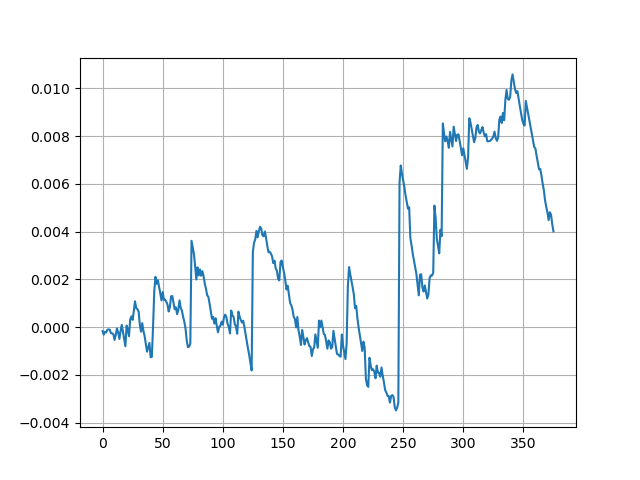

In [42]:
plt.figure()
plt.plot(np.cumsum(out['return'].values)/out.shape[0])
plt.grid(True)

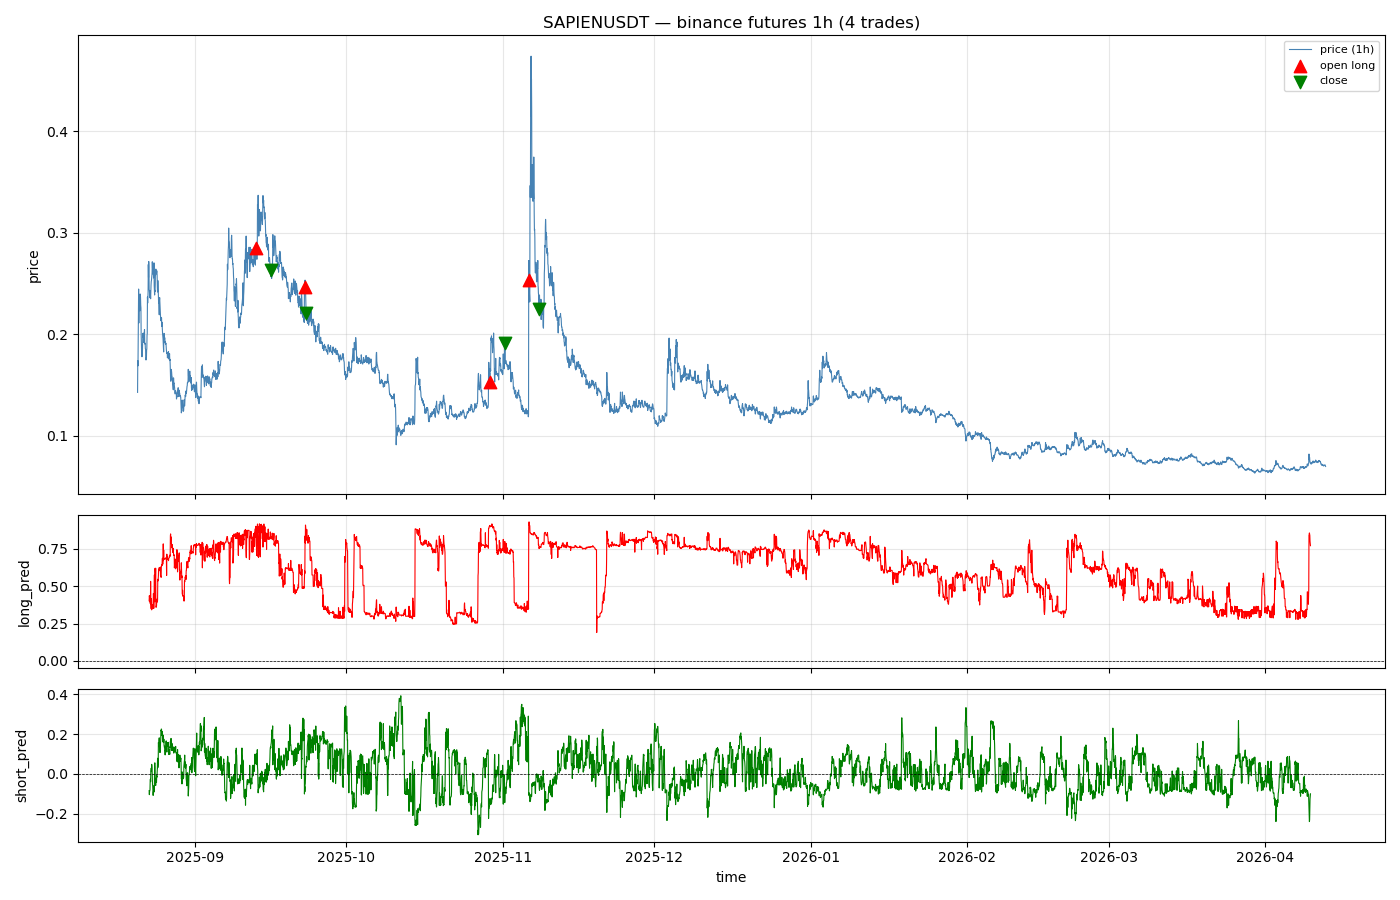

In [57]:
tb.showTrade(dl, out, 'SAPIENUSDT', long_pred= long_valid, short_pred = short_valid, O = O_valid)